In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [34]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [35]:
print("Loading MNIST dataset...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

X = X.astype('float32')
y = y.astype('int')

print("Total samples:", X.shape[0])
print("Total features:", X.shape[1])

Loading MNIST dataset...
Total samples: 70000
Total features: 784


In [36]:
X = X / 255.0

X = X[:20000]
y = y[:20000]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify = y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training Samples: 16000
Testing samples: 4000


In [37]:
activations = ['logistic', 'relu', 'tanh']
results = {}
training_times = {}
accuracies = {}

In [38]:
for activation in activations:
    print("\n----------------------------")
    print("Training with:", activation)
    print("------------------------------")

    start_time = time.time()

    model = MLPClassifier(
        hidden_layer_sizes=(128,),
        activation=activation,
        solver='adam',
        max_iter=100,
        batch_size=128,
        random_state=42,
        verbose=False
    )

    model.fit(X_train, y_train)

    end_time = time.time()

    training_time = end_time - start_time

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    results[activation] = model
    training_times[activation] = training_time
    accuracies[activation] = accuracy * 100

    print("Training time: {:.2f} seconds".format(training_time))
    print("Number of iterations:", model.n_iter_)
    print("Test accuracy: {:.2f}%".format(accuracy * 100))


----------------------------
Training with: logistic
------------------------------
Training time: 56.44 seconds
Number of iterations: 99
Test accuracy: 95.58%

----------------------------
Training with: relu
------------------------------
Training time: 28.14 seconds
Number of iterations: 56
Test accuracy: 96.23%

----------------------------
Training with: tanh
------------------------------
Training time: 28.16 seconds
Number of iterations: 61
Test accuracy: 95.80%


In [39]:
print("\n--------------------------------------------------------------")
print("ACTIVATION FUNCTION COMPARISON")
print("{:<12} {:<15} {:<15} {:<15}".format(
    "Activation", "Time(sec)", "Iterations", "Accuracy(%)"
))
for activation in activations:
    model = results[activation]
    print("{:<12} {:<15.2f} {:<15} {:<15.2f}".format(
        activation,
        training_times[activation],
        model.n_iter_,
        accuracy_score(y_test, model.predict(X_test))*100
    ))


--------------------------------------------------------------
ACTIVATION FUNCTION COMPARISON
Activation   Time(sec)       Iterations      Accuracy(%)    
logistic     56.44           99              95.58          
relu         28.14           56              96.23          
tanh         28.16           61              95.80          


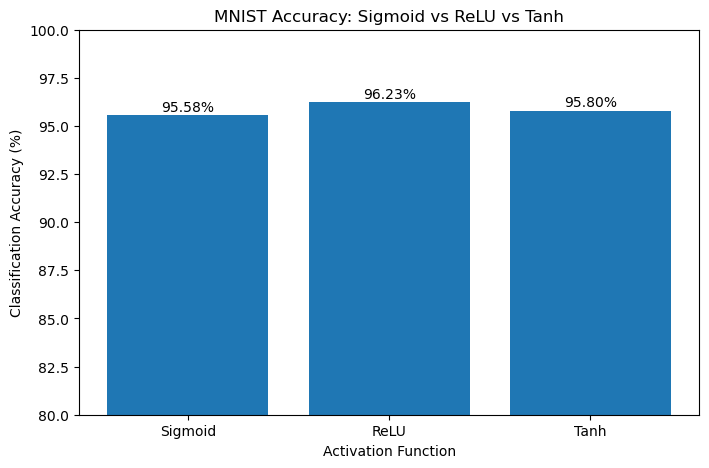

In [40]:
plt.figure(figsize=(8,5))
plt.bar(['Sigmoid', 'ReLU', 'Tanh'],
        [accuracies['logistic'], accuracies['relu'], accuracies['tanh']])
plt.xlabel('Activation Function')
plt.ylabel('Classification Accuracy (%)')
plt.title("MNIST Accuracy: Sigmoid vs ReLU vs Tanh")
plt.ylim(80, 100)

for i, value in enumerate(
    [
        accuracies['logistic'],
        accuracies['relu'],
        accuracies['tanh']
    ]
):
    plt.text(i, value + 0.2, f"{value:.2f}%", ha='center')

plt.show()

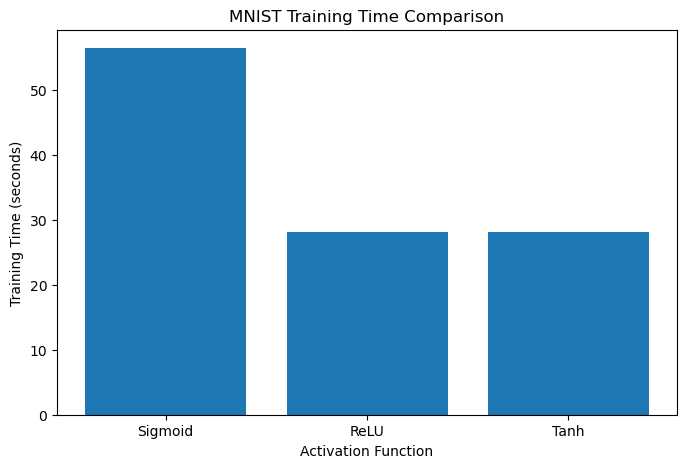

In [41]:
plt.figure(figsize=(8, 5))
plt.bar(
    ['Sigmoid', 'ReLU', 'Tanh'],
    [
        
        training_times['logistic'],
        training_times['relu'],
        training_times['tanh']
    ]
)

plt.xlabel('Activation Function')
plt.ylabel('Training Time (seconds)')
plt.title("MNIST Training Time Comparison")
plt.show()

In [ ]:
model = results[activation]
plt.plot(
    range(1, len(model.loss_curve_) + 1),
    model.loss_curve_,
    label=activation
)

plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title("Convergance Comparison")
plt.legend()
plt.grid(True)
plt.show()